# Layer-1 and Layer-2 Self-Attention Ablation — Query Position 1

**Goal:** Test whether self-attention *within layer 1* and *within layer 2* (Dr. Liu's
1-indexed convention, i.e. HF 0-indexed `model.model.layers[0]` and `model.model.layers[1]`)
is causally responsible for the gate-vector sign flip observed at token position 1
(relative to position 0). This notebook runs three conditions:

1. **Layer-1-only ablation** — block attn(pos1→pos0) at layer 1 alone, read out layer 1.
2. **Layer-2-only ablation** — block attn(pos1→pos0) at layer 2 alone, read out layer 2.
   (1) and (2) are independent single-layer interventions, each its own fresh forward pass —
   layer 1's ablation is **not** present when testing layer 2 in isolation.
3. **Combined/propagated ablation** — block attn(pos1→pos0) at **both** layer 1 and layer 2
   *simultaneously, in the same forward pass*, and read out layer 2. Because this is one
   forward pass, layer 2 here processes the residual stream that already reflects layer 1's
   ablation — i.e. layer 1's perturbation propagates into layer 2's input, on top of layer 2's
   own local attention block. Comparing condition (3) against condition (2) isolates the
   causal contribution of layer 1's ablation *propagating through* to layer 2, as opposed to
   layer 2's local ablation alone.

**Intervention:** For query position 1 at a given layer `L`, block attention to key
position 0 (set the pre-softmax score to `-inf`). Because the causal mask only
allows query position 1 to see keys `{0, 1}`, removing key 0 automatically forces
softmax to put 100% of the attention weight on key 1 (itself) — no manual
renormalization needed.

**Indexing note:** `LAYERS_TO_TEST = [0, 1]` are 0-indexed HF layers
(`model.model.layers[0]`, `model.model.layers[1]`), corresponding to Dr. Liu's
1-indexed "layer 1" and "layer 2". Confirm this matches the layer where
`verify_ma_circuit_layer2.py` located neuron 2427 before trusting the result.

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_PATH = "/home/samuel/research/llmattacks/llm-attacks/DIR/Llama-3.1-8B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16

# 0-indexed HF layers to intervene on, run in this order.
# LAYERS_TO_TEST[0] == 0  -> Dr. Liu's 1-indexed "layer 1"
# LAYERS_TO_TEST[1] == 1  -> Dr. Liu's 1-indexed "layer 2"
LAYERS_TO_TEST = [0, 1]
LAYER_LABELS = {0: "layer 1", 1: "layer 2"}  # Dr. Liu's 1-indexed naming, for titles/filenames

NEURON_IDX = 2427  # MA-implicated gate neuron
QUERY_POS = 1       # token position under test
KEY_POS_TO_BLOCK = 0

OUTPUT_DIR = "outputs/attention_ablation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

torch.manual_seed(0)

In [2]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=DTYPE,
    attn_implementation="eager",  # required: need explicit additive attention_mask access
).to(DEVICE)
model.eval()
print(model.config.num_hidden_layers, "layers | hidden_size:", model.config.hidden_size)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

32 layers | hidden_size: 4096


## Step 0 — Verify layer indexing empirically (don't trust convention alone)

Per project convention, `hidden_states[i]` = output of `model.model.layers[i-1]`.
So Dr. Liu's "layer 1" and "layer 2" (matching his MATLAB, 1-indexed analysis) most likely
correspond to `model.model.layers[0]` and `model.model.layers[1]` in HF's 0-indexed
`ModuleList` — this is exactly `LAYERS_TO_TEST` above. Rather than trust that mapping
blindly, re-derive which HF indices actually contain the MA circuit: check `down_proj`'s
column for neuron 2427 and see which candidate layer's row-norm is dominated by the three
MA channels (788, 1384, 4062), same test as `verify_ma_circuit_layer2.py`.

In [3]:
len(model.model.layers)

32

## Prepare input

Replace `PROMPT` with one of your existing harmful/harmless examples. `add_special_tokens=False`
with an explicit BOS assertion, per established convention — avoids silently
double-adding BOS depending on tokenizer defaults.

In [4]:
PROMPT = "Tell me a joke"  # placeholder — replace with your dataset example

BOS_ID = tokenizer.bos_token_id
ids = tokenizer.encode(PROMPT, add_special_tokens=False)
assert ids[0] != BOS_ID, "First token unexpectedly matches BOS id — check tokenizer/prompt"

input_ids = torch.tensor([ids], device=DEVICE)
print("token ids:", ids)
print("tokens:   ", [tokenizer.decode([t]) for t in ids])
assert input_ids.shape[1] > QUERY_POS, "sequence too short for QUERY_POS"

token ids: [41551, 757, 264, 22380]
tokens:    ['Tell', ' me', ' a', ' joke']


## Helpers: capture the gate vector at one or more layers, position `QUERY_POS`

`capture_activations` takes a **list** of layers to instrument (`capture_layers`), so a single
forward pass can read out activations at multiple layers at once — needed for the combined
condition below, where we block attention at layers 1 and 2 together but want to confirm layer
1's readout is unaffected by layer 2's hook while inspecting layer 2's propagated readout.

For each layer in `capture_layers`, it hooks `model.model.layers[L].mlp` with a
`forward_pre_hook` to capture its input `x` (the post-RMSNorm, post-gamma residual stream —
exactly what feeds `gate_proj`), from which we compute the full 14,336-dim gate vector
`x @ W_gate.T` ourselves.

`extra_fwd_pre_hooks` is a list of `(module, hook_fn)` pairs applied on top — used to register
the attention-blocking hook(s) on whichever `self_attn` module(s) are under test.
`make_block_hook` is unchanged from the layer-2-only notebook.

In [5]:
def capture_activations(model, input_ids, capture_layers, extra_fwd_pre_hooks=None):
    """
    Runs a single forward pass, optionally with extra forward_pre_hooks registered
    on self_attn modules (for the attention-blocking intervention).
    Returns a dict {L: {'gate': ..., 'attn': ...}} for every L in
    capture_layers, all read out at position QUERY_POS:
      - 'gate': the full gate vector (14336,)
      - 'attn': the attention pattern at layer L, for sanity-checking any block
    """
    captured = {}
    handles = []

    def make_mlp_input_hook(L):
        def hook(module, args):
            captured[('mlp_input', L)] = args[0].detach()
        return hook

    for L in capture_layers:
        handles.append(model.model.layers[L].mlp.register_forward_pre_hook(make_mlp_input_hook(L)))

    if extra_fwd_pre_hooks:
        for module, hook_fn in extra_fwd_pre_hooks:
            handles.append(module.register_forward_pre_hook(hook_fn, with_kwargs=True))

    try:
        with torch.no_grad():
            out = model(input_ids=input_ids, output_attentions=True)
    finally:
        for h in handles:
            h.remove()

    results = {}
    for L in capture_layers:
        x = captured[('mlp_input', L)][0, QUERY_POS, :].to(torch.float32)          # (4096,)
        W_gate = model.model.layers[L].mlp.gate_proj.weight.detach().to(torch.float32)  # (14336, 4096)
        gate_vec = x @ W_gate.T                                                    # (14336,)

        attn_pattern_L = out.attentions[L][0, :, QUERY_POS, :].to(torch.float32)   # (n_heads, seq)

        results[L] = dict(
            gate=gate_vec.cpu().numpy(),
            attn=attn_pattern_L.cpu().numpy(),
        )
    return results


def make_block_hook(query_pos, key_pos, dtype):
    fill_value = torch.finfo(dtype).min

    def hook(module, args, kwargs):
        attention_mask = kwargs.get('attention_mask', None)
        assert attention_mask is not None, (
            "attention_mask kwarg not found on self_attn — check transformers version"
        )
        attention_mask = attention_mask.clone()
        attention_mask[:, :, query_pos, key_pos] = fill_value
        kwargs['attention_mask'] = attention_mask
        return args, kwargs

    return hook

## Steps 1–2 — Independent single-layer ablation: layer 1 alone, then layer 2 alone

For each `L` in `LAYERS_TO_TEST` (in order: layer 1, then layer 2), we run two **separate**
full forward passes:
1. **Baseline** — no attention-blocking hooks (only the gate-vector capture hook).
2. **Intervention** — attention from query pos 1 to key pos 0 blocked at layer `L` only.

These two conditions never involve blocking both layers at once — that's the combined
condition in Step 2b below. Results for both layers are stored in `results[L]`.

In [6]:
results = {}

for L in LAYERS_TO_TEST:
    label = LAYER_LABELS[L]
    print(f"\n=== {label} (HF index {L}), independent ablation ===")

    baseline = capture_activations(model, input_ids, capture_layers=[L])[L]
    print(f"baseline attn pattern at {label}, query pos {QUERY_POS} (per head, keys 0..{QUERY_POS}):")
    print(baseline['attn'][:, :QUERY_POS + 1])
    print(f"gate_baseline[neuron {NEURON_IDX}] =", baseline['gate'][NEURON_IDX])

    block_hook = make_block_hook(QUERY_POS, KEY_POS_TO_BLOCK, dtype=DTYPE)
    target_module = model.model.layers[L].self_attn
    intervention = capture_activations(
        model, input_ids, capture_layers=[L], extra_fwd_pre_hooks=[(target_module, block_hook)]
    )[L]
    print(f"intervention attn pattern at {label}, query pos {QUERY_POS} (per head, keys 0..{QUERY_POS}):")
    print(intervention['attn'][:, :QUERY_POS + 1])
    print("-> expect ~0 in the key-0 column and ~1 in the key-1 column, for every head")
    print(f"gate_intervention[neuron {NEURON_IDX}] =", intervention['gate'][NEURON_IDX])

    results[L] = dict(
        gate_baseline=baseline['gate'],
        gate_intervention=intervention['gate'],
        attn_baseline=baseline['attn'],
        attn_intervention=intervention['attn'],
    )


=== layer 1 (HF index 0), independent ablation ===
baseline attn pattern at layer 1, query pos 1 (per head, keys 0..1):
[[0.86328125 0.13671875]
 [0.90234375 0.09814453]
 [0.890625   0.10986328]
 [0.55859375 0.44140625]
 [0.5546875  0.4453125 ]
 [0.484375   0.515625  ]
 [0.73828125 0.26367188]
 [0.7421875  0.25585938]
 [0.4375     0.5625    ]
 [0.23925781 0.76171875]
 [0.4375     0.5625    ]
 [0.5546875  0.4453125 ]
 [0.46875    0.53125   ]
 [0.44140625 0.55859375]
 [0.40820312 0.59375   ]
 [0.37695312 0.62109375]
 [0.48046875 0.51953125]
 [0.64453125 0.35546875]
 [0.34570312 0.65234375]
 [0.7109375  0.28710938]
 [0.1640625  0.8359375 ]
 [0.93359375 0.06640625]
 [0.859375   0.140625  ]
 [0.80859375 0.19238281]
 [0.92578125 0.07568359]
 [0.62109375 0.37695312]
 [0.4609375  0.5390625 ]
 [0.30078125 0.69921875]
 [0.6640625  0.3359375 ]
 [0.77734375 0.22363281]
 [0.04833984 0.953125  ]
 [0.04077148 0.9609375 ]]
gate_baseline[neuron 2427] = 0.035303157
intervention attn pattern at layer 1,

## Step 2b — Combined/propagated ablation: block layer 1 AND layer 2 in the same forward pass

This is the key new condition. We register the attention-block hook on **both**
`model.model.layers[0].self_attn` and `model.model.layers[1].self_attn` at once, in a single
forward pass, and read out activations at **both** layers.

- The layer-1 readout in this combined pass should be numerically identical to the
  layer-1-only intervention above (Transformer layers are strictly causal/feed-forward across
  depth, so layer 2's hook cannot affect layer 1's computation). We assert this as a sanity
  check.
- The layer-2 readout in this combined pass is the interesting one: layer 2 here is processing
  a residual stream that already reflects layer 1's ablation, on top of its own local
  attention block. Comparing this against the layer-2-only intervention (`results[1]`, where
  layer 1 was left untouched) isolates how much of the effect at layer 2 is *caused by
  layer 1's ablation propagating forward*, versus layer 2's own local attention block.

In [7]:
block_hook_L0 = make_block_hook(QUERY_POS, KEY_POS_TO_BLOCK, dtype=DTYPE)
block_hook_L1 = make_block_hook(QUERY_POS, KEY_POS_TO_BLOCK, dtype=DTYPE)
target_L0 = model.model.layers[0].self_attn
target_L1 = model.model.layers[1].self_attn

combined = capture_activations(
    model, input_ids, capture_layers=[0, 1],
    extra_fwd_pre_hooks=[(target_L0, block_hook_L0), (target_L1, block_hook_L1)],
)

# Sanity check: layer-1 readout under the combined hook must match the layer-1-only
# intervention exactly, since layer 2's hook cannot causally affect layer 1's forward pass.
assert np.allclose(combined[0]['gate'], results[0]['gate_intervention']), (
    "combined layer-1 gate readout diverged from layer-1-only intervention — "
    "something upstream of layer 1 is not deterministic, or the hook wiring is wrong"
)
print("sanity check passed: layer-1 readout under combined hooking matches layer-1-only intervention")

results['combined'] = dict(
    gate_L0=combined[0]['gate'],
    attn_L0=combined[0]['attn'],
    gate_L1=combined[1]['gate'],
    attn_L1=combined[1]['attn'],
)

print(f"\ngate[{NEURON_IDX}] at layer 2 readout:")
print(f"  baseline (nothing blocked)        = {results[1]['gate_baseline'][NEURON_IDX]:.4f}")
print(f"  layer-2-only ablation              = {results[1]['gate_intervention'][NEURON_IDX]:.4f}")
print(f"  combined (layer-1 + layer-2 ablated) = {results['combined']['gate_L1'][NEURON_IDX]:.4f}")

sanity check passed: layer-1 readout under combined hooking matches layer-1-only intervention

gate[2427] at layer 2 readout:
  baseline (nothing blocked)        = -5.7004
  layer-2-only ablation              = 1.8713
  combined (layer-1 + layer-2 ablated) = 18.3708


## Step 3 — Plot: gate vector at token position 1, baseline vs. intervention, per layer (independent)

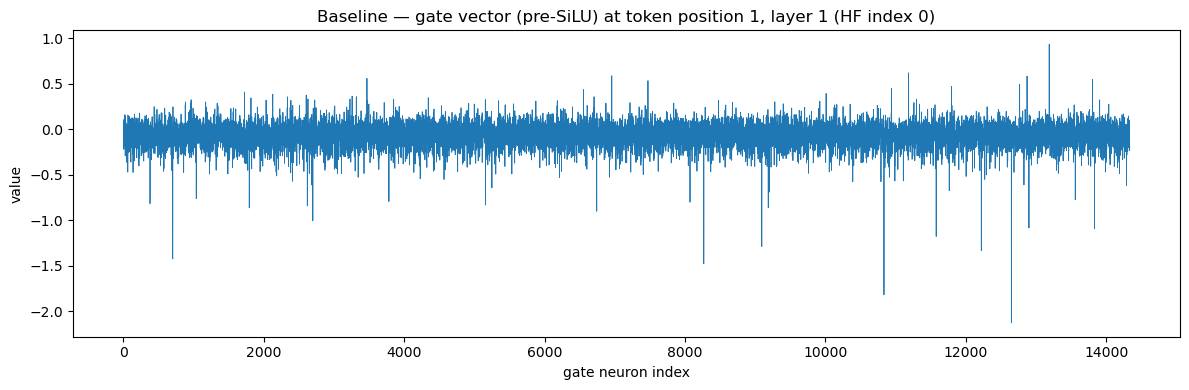

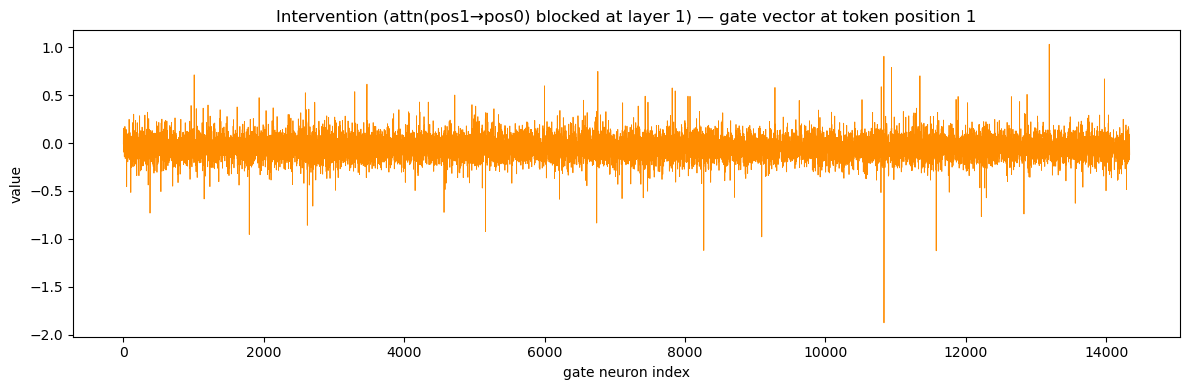

layer 1: neuron 2427: baseline = 0.035  intervention = 0.036
layer 1: sign changed after intervention: False


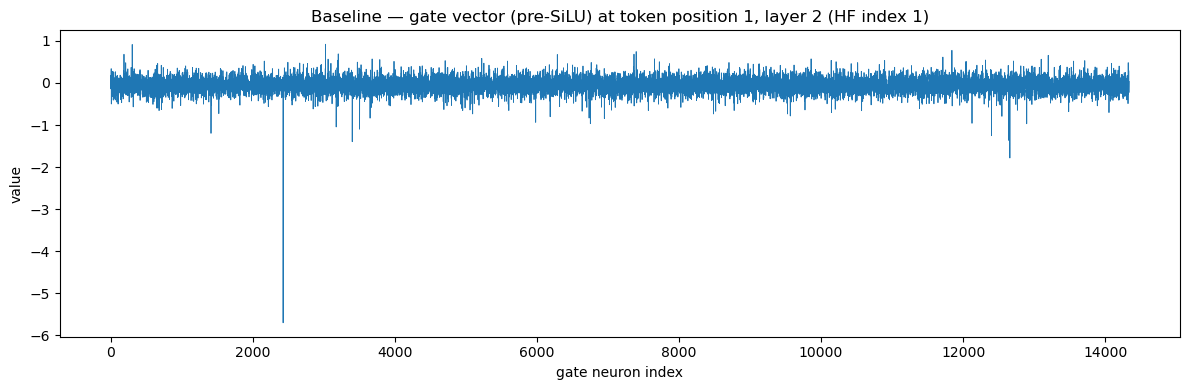

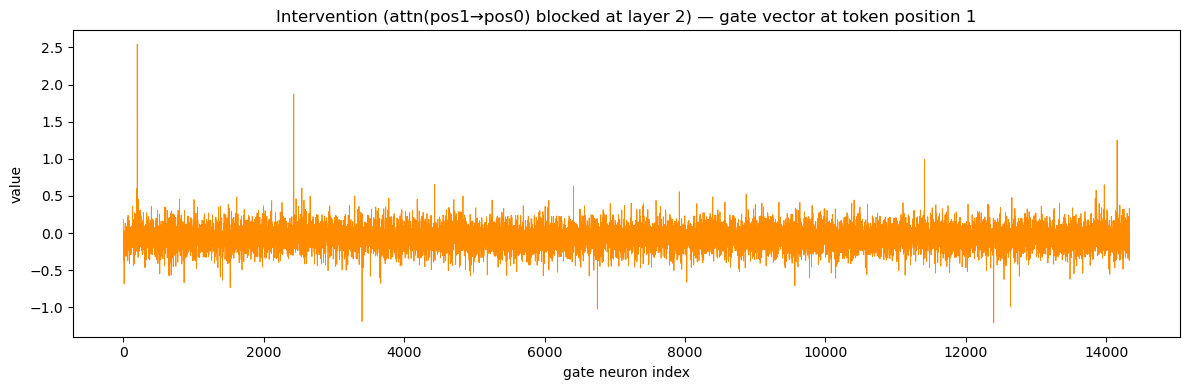

layer 2: neuron 2427: baseline = -5.700  intervention = 1.871
layer 2: sign changed after intervention: True


In [8]:
for L in LAYERS_TO_TEST:
    label = LAYER_LABELS[L]
    r = results[L]

    plot_specs = [
        ("baseline", r['gate_baseline'], 'C0',
         f"Baseline — gate vector (pre-SiLU) at token position {QUERY_POS}, {label} (HF index {L})"),
        ("intervention", r['gate_intervention'], 'darkorange',
         f"Intervention (attn(pos1→pos0) blocked at {label}) — gate vector at token position {QUERY_POS}"),
    ]

    for name, gate_vec, color, title in plot_specs:
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(gate_vec, linewidth=0.6, color=color)
        ax.set_title(title)
        ax.set_xlabel("gate neuron index")
        ax.set_ylabel("value")
        plt.tight_layout()
        fname = f"gate_vector_{label.replace(' ', '')}_{name}_attn_ablation_pos1.pdf"
        plt.savefig(os.path.join(OUTPUT_DIR, fname))
        plt.show()

    print(f"{label}: neuron {NEURON_IDX}: baseline = {r['gate_baseline'][NEURON_IDX]:.3f}  "
          f"intervention = {r['gate_intervention'][NEURON_IDX]:.3f}")
    print(f"{label}: sign changed after intervention: "
          f"{np.sign(r['gate_baseline'][NEURON_IDX]) != np.sign(r['gate_intervention'][NEURON_IDX])}")

## Step 4 — Plot: gate vector at layer 2, three-way comparison

Baseline (nothing blocked) vs. layer-2-only ablation vs. combined ablation
(layer 1 **and** layer 2 blocked, layer 1's perturbation propagated into layer 2's input).
Any difference between the second and third rows is the propagation effect.

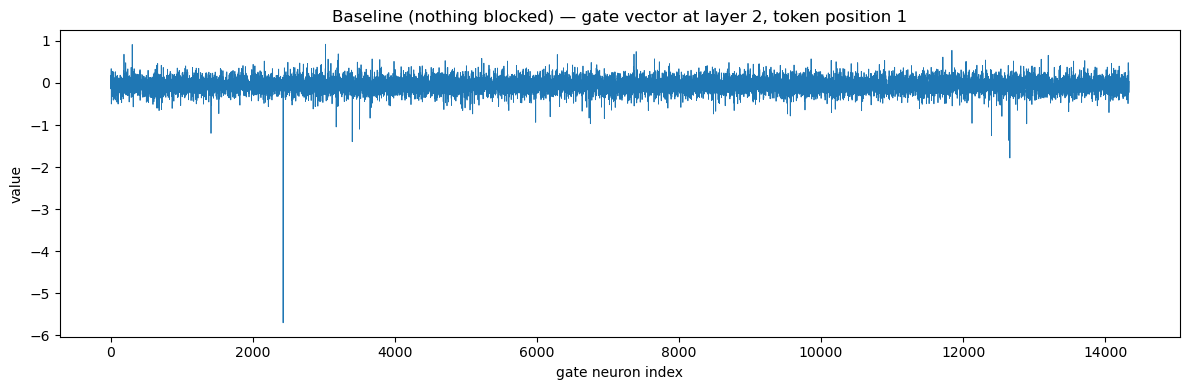

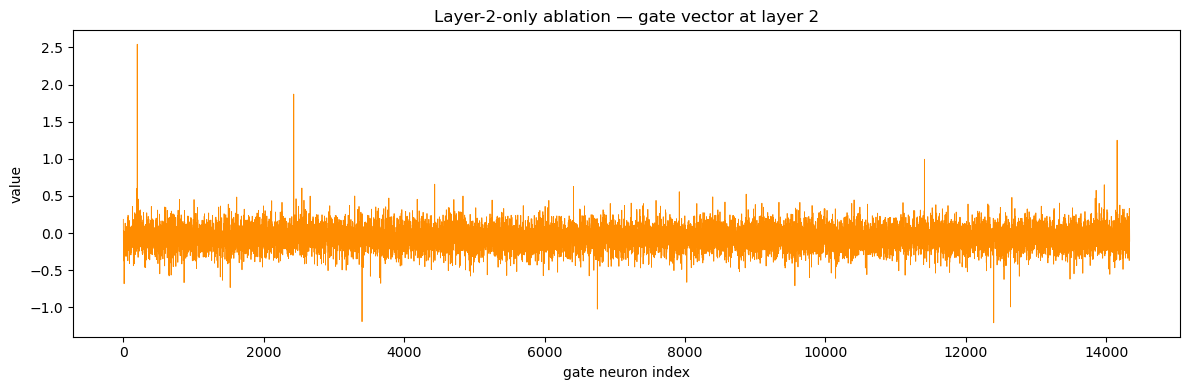

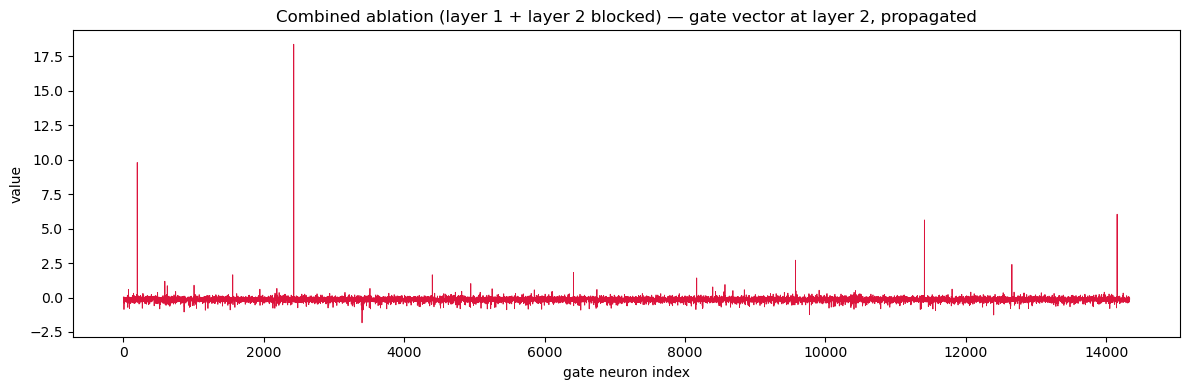

neuron 2427 at layer 2:
  baseline            = -5.7004
  layer-2-only        = 1.8713
  combined(1+2)       = 18.3708
  propagation delta (combined - layer-2-only) = 16.4995


In [9]:
gate_baseline_L1 = results[1]['gate_baseline']
gate_layer2_only_L1 = results[1]['gate_intervention']
gate_combined_L1 = results['combined']['gate_L1']

plot_specs = [
    ("baseline", gate_baseline_L1, 'C0',
     f"Baseline (nothing blocked) — gate vector at layer 2, token position {QUERY_POS}"),
    ("layer2_only", gate_layer2_only_L1, 'darkorange',
     "Layer-2-only ablation — gate vector at layer 2"),
    ("combined", gate_combined_L1, 'crimson',
     "Combined ablation (layer 1 + layer 2 blocked) — gate vector at layer 2, propagated"),
]

for name, gate_vec, color, title in plot_specs:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(gate_vec, linewidth=0.6, color=color)
    ax.set_title(title)
    ax.set_xlabel("gate neuron index")
    ax.set_ylabel("value")
    plt.tight_layout()
    fname = f"gate_vector_layer2_propagation_{name}_pos1.pdf"
    plt.savefig(os.path.join(OUTPUT_DIR, fname))
    plt.show()

print(f"neuron {NEURON_IDX} at layer 2:")
print(f"  baseline            = {gate_baseline_L1[NEURON_IDX]:.4f}")
print(f"  layer-2-only        = {gate_layer2_only_L1[NEURON_IDX]:.4f}")
print(f"  combined(1+2)       = {gate_combined_L1[NEURON_IDX]:.4f}")
print(f"  propagation delta (combined - layer-2-only) = "
      f"{gate_combined_L1[NEURON_IDX] - gate_layer2_only_L1[NEURON_IDX]:.4f}")

## Step 5 — Cross-condition summary

In [10]:
gate_base_L1 = results[1]['gate_baseline'][NEURON_IDX]

rows = [
    ("layer-1-only",  results[0]['gate_baseline'][NEURON_IDX], results[0]['gate_intervention'][NEURON_IDX]),
    ("layer-2-only",  results[1]['gate_baseline'][NEURON_IDX], results[1]['gate_intervention'][NEURON_IDX]),
    ("combined@L2",   results[1]['gate_baseline'][NEURON_IDX], results['combined']['gate_L1'][NEURON_IDX]),
]

print(f"{'condition':<14}{'gate base':>12}{'gate interv':>14}{'sign flip':>12}")
for name, base, interv in rows:
    flip = np.sign(base) != np.sign(interv)
    print(f"{name:<14}{base:>12.3f}{interv:>14.3f}{str(flip):>12}")

print(f"\npropagation-specific gate delta at layer 2 (combined - layer-2-only) = "
      f"{results['combined']['gate_L1'][NEURON_IDX] - results[1]['gate_intervention'][NEURON_IDX]:.4f}")

condition        gate base   gate interv   sign flip
layer-1-only         0.035         0.036       False
layer-2-only        -5.700         1.871        True
combined@L2         -5.700        18.371        True

propagation-specific gate delta at layer 2 (combined - layer-2-only) = 16.4995


## Interpretation

- **`layer-1-only` and `layer-2-only` rows** reproduce the original independent-layer result:
  whether each layer's self-attention, in isolation, is sufficient to flip the sign of
  `gate[2427]`.

- **`combined@L2` vs. `layer-2-only`** is the propagation test. If `combined@L2` is close to
  `layer-2-only` (small propagation delta): layer 2's own local attention block already
  accounts for essentially all of the effect at layer 2, and layer 1's ablation does not
  meaningfully propagate forward — layer 2 is "self-sufficient" for this effect.

- **If `combined@L2` diverges substantially from `layer-2-only`** (large propagation delta):
  layer 1's ablation is causally contributing to what happens at layer 2, independent of
  layer 2's own local block — i.e. the effect is genuinely propagated through the residual
  stream from layer 1 into layer 2, not just re-derived locally at layer 2. This would support
  treating layers 1–2 as a joint circuit rather than two independent single-layer causes.

- The sanity-check assertion in Step 2b (`combined` layer-1 readout == `layer-1-only`
  intervention) should always pass given the model's strict causal depth-wise structure; if it
  ever fails, suspect non-determinism (e.g. a non-greedy/sampling op somewhere) or a hook
  registered on the wrong module.